# WTA Tennis Analytics — Sabalenka vs Gauff

**Objetivo:** Analizar el rendimiento histórico de Aryna Sabalenka y Coco Gauff en el circuito WTA, con foco en su head-to-head y predicción de su próximo enfrentamiento.

**Motivación personal:** soy fan del tenis femenino y quiero combinar mi pasión por el deporte con mis habilidades de análisis de datos.

**Dataset:** Jeff Sackmann's WTA Tennis Dataset — datos históricos de todos los partidos WTA desde 1968, incluyendo estadísticas de servicio, resultados y rankings.

## Tabla de contenidos

1. **Carga y exploración de datos** — 16K partidos WTA (2020-2026)
2. **Análisis del tour** — partidos por año, top jugadoras, superficies
3. **Head to Head: Sabalenka vs Gauff** — la rivalidad más intensa del tour
4. **Estadísticas de servicio** — aces, break points, primer servicio
5. **Red de rivalidades** — Network graph con NetworkX
6. **Modelo predictivo** — Random Forest para predicción de partidos

In [1]:
import pandas as pd
import os

# Cargar todos los CSVs de la carpeta data
archivos = [f for f in os.listdir('../data/') if f.startswith('wta_matches') and f.endswith('.csv')]
archivos.sort()

print(f"Archivos encontrados: {len(archivos)}\n")
for f in archivos:
    print(f"  📄 {f}")

# Cargar y unir todos
dfs = []
for f in archivos:
    df_temp = pd.read_csv(f'../data/{f}')
    dfs.append(df_temp)
    print(f"  ✓ {f}: {len(df_temp)} partidos")

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal: {len(df):,} partidos cargados")
print(f"Columnas: {df.shape[1]}")

Archivos encontrados: 7

  📄 wta_matches_2020.csv
  📄 wta_matches_2021.csv
  📄 wta_matches_2022.csv
  📄 wta_matches_2023.csv
  📄 wta_matches_2024.csv
  📄 wta_matches_2025.csv
  📄 wta_matches_2026.csv
  ✓ wta_matches_2020.csv: 1276 partidos
  ✓ wta_matches_2021.csv: 2597 partidos
  ✓ wta_matches_2022.csv: 2594 partidos
  ✓ wta_matches_2023.csv: 2810 partidos
  ✓ wta_matches_2024.csv: 2689 partidos
  ✓ wta_matches_2025.csv: 2795 partidos
  ✓ wta_matches_2026.csv: 1295 partidos

Total: 16,056 partidos cargados
Columnas: 49


In [2]:
# Ver las columnas disponibles
print("Columnas del dataset:\n")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

Columnas del dataset:

   1. tourney_id
   2. tourney_name
   3. surface
   4. draw_size
   5. tourney_level
   6. tourney_date
   7. match_num
   8. winner_id
   9. winner_seed
  10. winner_entry
  11. winner_name
  12. winner_hand
  13. winner_ht
  14. winner_ioc
  15. winner_age
  16. loser_id
  17. loser_seed
  18. loser_entry
  19. loser_name
  20. loser_hand
  21. loser_ht
  22. loser_ioc
  23. loser_age
  24. score
  25. best_of
  26. round
  27. minutes
  28. w_ace
  29. w_df
  30. w_svpt
  31. w_1stIn
  32. w_1stWon
  33. w_2ndWon
  34. w_SvGms
  35. w_bpSaved
  36. w_bpFaced
  37. l_ace
  38. l_df
  39. l_svpt
  40. l_1stIn
  41. l_1stWon
  42. l_2ndWon
  43. l_SvGms
  44. l_bpSaved
  45. l_bpFaced
  46. winner_rank
  47. winner_rank_points
  48. loser_rank
  49. loser_rank_points


## Dataset — WTA Match Results

**Fuente:** Jeff Sackmann's Tennis Archive (via [Aneeshers/tennis-sackmann-archive](https://github.com/Aneeshers/tennis-sackmann-archive))

**Período:** 2020 — 2026 (hasta Roland Garros 2026)

**Tamaño:** 16,056 partidos | 49 columnas

**Estructura de las columnas:**

**Torneo:** `tourney_name` (nombre), `surface` (Hard/Clay/Grass), `tourney_level` (G=Grand Slam, P=Premier), `round` (F=final, SF=semi, QF=cuartos)

**Jugadoras:** `winner_name`/`loser_name`, `winner_hand` (R/L), `winner_ht` (altura cm), `winner_ioc` (país), `winner_age`, `winner_rank`

**Resultado:** `score` (ej: "6-4 7-5"), `minutes` (duración)

**Estadísticas de servicio (w_ = ganadora, l_ = perdedora):**
- `ace` — aces | `df` — doble faltas
- `svpt` — puntos de servicio | `1stIn` — primeros servicios adentro
- `1stWon` — puntos ganados con 1er servicio | `2ndWon` — con 2do servicio
- `SvGms` — games de servicio | `bpSaved`/`bpFaced` — break points salvados/enfrentados

In [3]:
# ¿Cuántos partidos por año?
partidos_año = df['tourney_date'].astype(str).str[:4].value_counts().sort_index()

print("Partidos por año:\n")
for año, cantidad in partidos_año.items():
    barra = "█" * (cantidad // 50)
    print(f"  {año}: {cantidad:,} partidos  {barra}")

Partidos por año:

  2020: 1,276 partidos  █████████████████████████
  2021: 2,597 partidos  ███████████████████████████████████████████████████
  2022: 2,594 partidos  ███████████████████████████████████████████████████
  2023: 2,810 partidos  ████████████████████████████████████████████████████████
  2024: 2,792 partidos  ███████████████████████████████████████████████████████
  2025: 2,692 partidos  █████████████████████████████████████████████████████
  2026: 1,295 partidos  █████████████████████████


In [4]:
# ¿En qué superficies se juega?
superficies = df['surface'].value_counts()

print("Partidos por superficie:\n")
for sup, cantidad in superficies.items():
    pct = cantidad / len(df) * 100
    print(f"  {sup:<10} {cantidad:,} partidos ({pct:.1f}%)")

Partidos por superficie:

  Hard       9,856 partidos (61.4%)
  Clay       4,512 partidos (28.1%)
  Grass      1,542 partidos (9.6%)
  clay       31 partidos (0.2%)


In [5]:
# Corregir "clay" → "Clay"
df['surface'] = df['surface'].str.title()

# Verificar
print("Superficies corregidas:\n")
for sup, cantidad in df['surface'].value_counts().items():
    pct = cantidad / len(df) * 100
    print(f"  {sup:<10} {cantidad:,} partidos ({pct:.1f}%)")

Superficies corregidas:

  Hard       9,856 partidos (61.4%)
  Clay       4,543 partidos (28.3%)
  Grass      1,542 partidos (9.6%)


In [6]:
def ranking_jugadoras(año=None):
    """Muestra top 15 jugadoras. Si pasás un año, filtra solo ese año."""
    if año:
        datos = df[df['tourney_date'].astype(str).str[:4] == str(año)]
        titulo = f"Top 15 jugadoras — {año}"
    else:
        datos = df
        titulo = "Top 15 jugadoras — 2020-2026 (general)"
    
    ganados = datos['winner_name'].value_counts()
    perdidos = datos['loser_name'].value_counts()
    total = (ganados.add(perdidos, fill_value=0)).astype(int).sort_values(ascending=False)
    wins = ganados.reindex(total.head(15).index, fill_value=0).astype(int)
    
    print(f"\n{titulo}\n")
    print(f"{'Jugadora':<25} {'Partidos':>10} {'Victorias':>10} {'Win Rate':>10}")
    print("-" * 58)
    
    for jugadora in total.head(15).index:
        t = total[jugadora]
        w = wins[jugadora]
        wr = w / t * 100
        print(f"{jugadora:<25} {t:>10} {w:>10} {wr:>9.1f}%")

# General
ranking_jugadoras()


Top 15 jugadoras — 2020-2026 (general)

Jugadora                    Partidos  Victorias   Win Rate
----------------------------------------------------------
Iga Swiatek                      415        338      81.4%
Aryna Sabalenka                  409        315      77.0%
Elena Rybakina                   399        284      71.2%
Jessica Pegula                   382        271      70.9%
Coco Gauff                       370        264      71.4%
Elise Mertens                    336        203      60.4%
Daria Kasatkina                  332        198      59.6%
Ekaterina Alexandrova            329        193      58.7%
Maria Sakkari                    323        191      59.1%
Jasmine Paolini                  305        178      58.4%
Veronika Kudermetova             297        167      56.2%
Jelena Ostapenko                 296        177      59.8%
Yulia Putintseva                 292        159      54.5%
Magda Linette                    291        148      50.9%
Ons Jabeur     

In [7]:
ranking_jugadoras(2022)


Top 15 jugadoras — 2022

Jugadora                    Partidos  Victorias   Win Rate
----------------------------------------------------------
Iga Swiatek                       76         67      88.2%
Caroline Garcia                   65         45      69.2%
Jessica Pegula                    64         43      67.2%
Elena Rybakina                    64         41      64.1%
Ons Jabeur                        64         47      73.4%
Veronika Kudermetova              63         43      68.3%
Daria Kasatkina                   63         41      65.1%
Maria Sakkari                     63         40      63.5%
Belinda Bencic                    61         42      68.9%
Coco Gauff                        61         38      62.3%
Shuai Zhang                       60         34      56.7%
Beatriz Haddad Maia               60         39      65.0%
Ajla Tomljanovic                  56         30      53.6%
Aryna Sabalenka                   55         33      60.0%
Paula Badosa                  

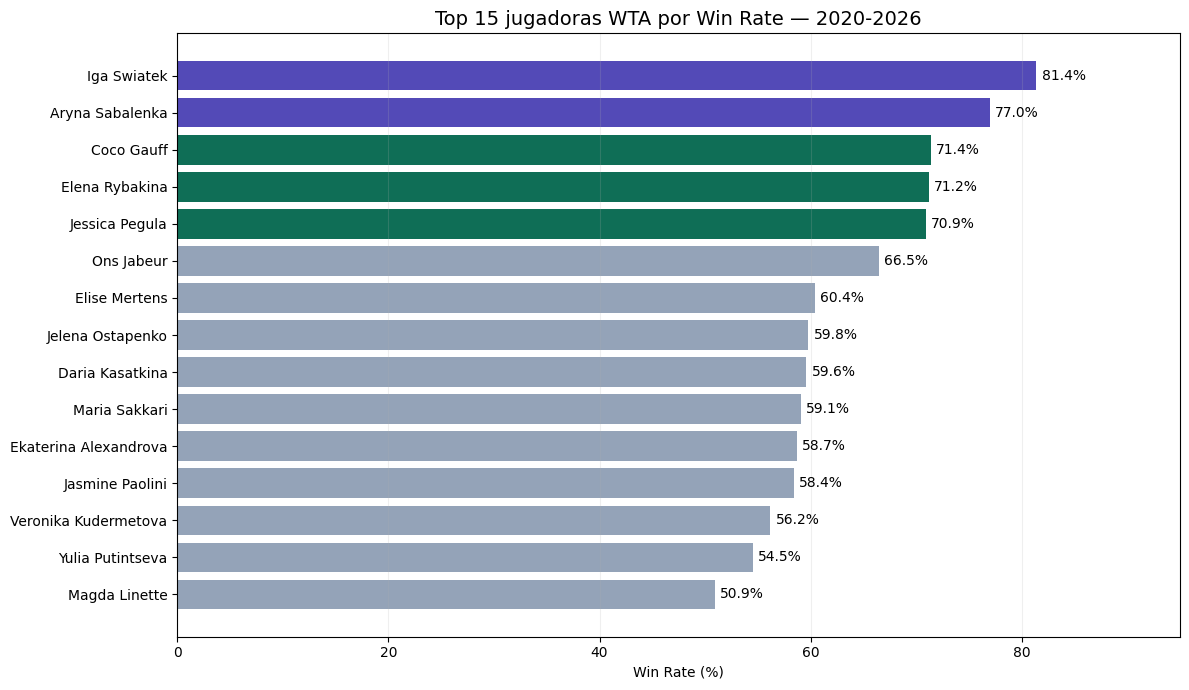

In [8]:
import matplotlib.pyplot as plt
def grafico_top15(año=None):
    """Gráfico de top 15 jugadoras por win rate. Filtra por año si se pasa."""
    if año:
        datos = df[df['tourney_date'].astype(str).str[:4] == str(año)]
        titulo = f'Top 15 jugadoras WTA por Win Rate — {año}'
        archivo = f'../outputs/01_top15_winrate_{año}.png'
    else:
        datos = df
        titulo = 'Top 15 jugadoras WTA por Win Rate — 2020-2026'
        archivo = '../outputs/01_top15_winrate_general.png'
    
    ganados = datos['winner_name'].value_counts()
    perdidos = datos['loser_name'].value_counts()
    total = (ganados.add(perdidos, fill_value=0)).astype(int).sort_values(ascending=False)
    
    top15 = total.head(15).index
    datos_g = pd.DataFrame({
        'partidos': [total[j] for j in top15],
        'victorias': [int(ganados.get(j, 0)) for j in top15],
    }, index=top15)
    
    datos_g['win_rate'] = (datos_g['victorias'] / datos_g['partidos'] * 100).round(1)
    datos_g = datos_g.sort_values('win_rate', ascending=True)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    colores = ['#534AB7' if wr >= 75 else '#0F6E56' if wr >= 70 else '#94A3B8' 
               for wr in datos_g['win_rate']]
    
    bars = ax.barh(datos_g.index, datos_g['win_rate'], color=colores)
    
    for bar, wr in zip(bars, datos_g['win_rate']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{wr}%', va='center', fontsize=10)
    
    ax.set_xlabel('Win Rate (%)')
    ax.set_title(titulo, fontsize=14)
    ax.set_xlim(0, 95)
    ax.grid(axis='x', alpha=0.2)
    
    plt.tight_layout()
    plt.savefig(archivo, dpi=100, bbox_inches='tight')
    plt.show()

# General
grafico_top15()

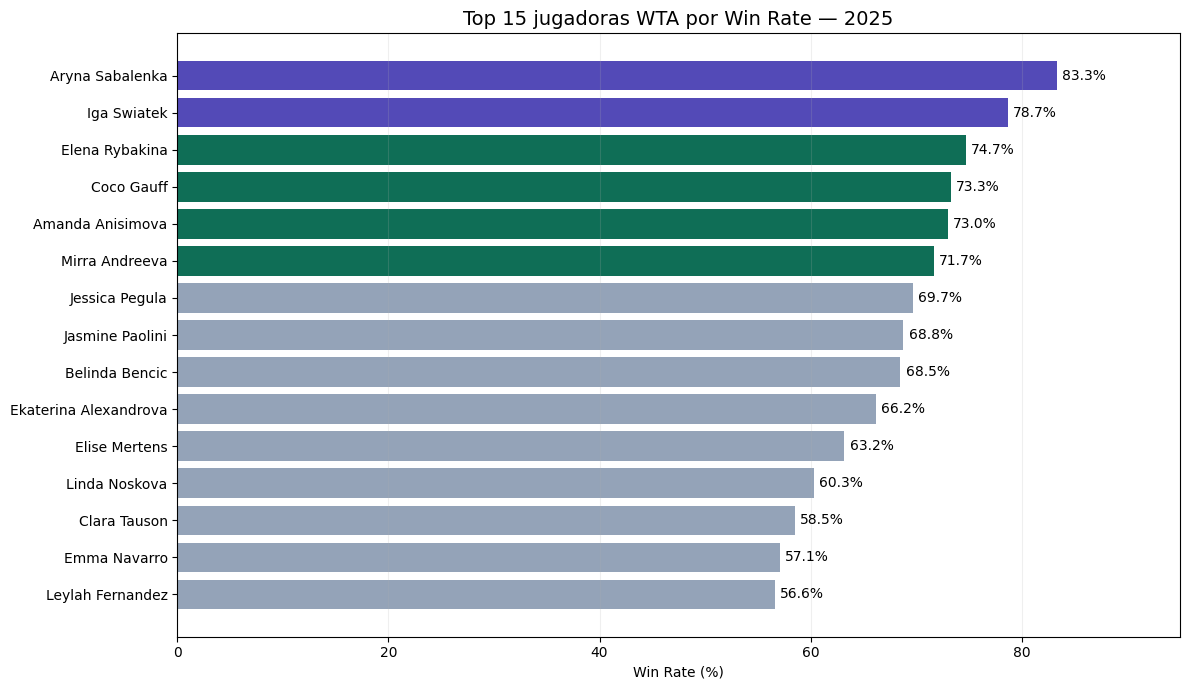

In [9]:
grafico_top15(2025)

In [10]:
#pip install plotly

In [11]:
pip install nbformat

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\saray\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
import plotly.express as px

# Calcular win rate por jugadora por año
registros = []

for año in range(2020, 2027):
    datos = df[df['tourney_date'].astype(str).str[:4] == str(año)]
    ganados = datos['winner_name'].value_counts()
    perdidos = datos['loser_name'].value_counts()
    total = (ganados.add(perdidos, fill_value=0)).astype(int).sort_values(ascending=False)
    
    for jugadora in total.head(10).index:
        wins = int(ganados.get(jugadora, 0))
        partidos = total[jugadora]
        registros.append({
            'año': str(año),
            'jugadora': jugadora,
            'partidos': partidos,
            'victorias': wins,
            'win_rate': round(wins / partidos * 100, 1)
        })

df_evolucion = pd.DataFrame(registros)

# Gráfico interactivo con dropdown por año
fig = px.bar(
    df_evolucion.sort_values(['año', 'win_rate'], ascending=[True, True]),
    x='win_rate',
    y='jugadora',
    animation_frame='año',
    orientation='h',
    color='win_rate',
    color_continuous_scale=['#94A3B8', '#0F6E56', '#534AB7'],
    range_x=[0, 100],
    range_color=[50, 90],
    text='win_rate',
    title='Top 10 jugadoras WTA por Win Rate — Año a año',
    labels={'win_rate': 'Win Rate (%)', 'jugadora': '', 'año': 'Año'}
)

fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(height=500, showlegend=False)
fig.show()

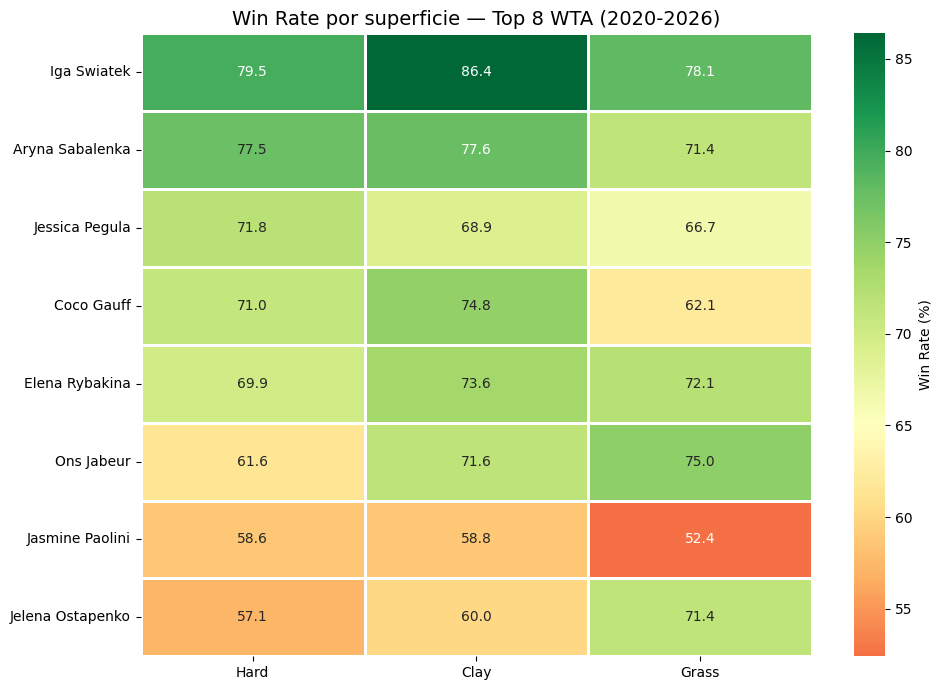

In [13]:
import seaborn as sns
def heatmap_superficies(año=None):
    """Heatmap de win rate por superficie. Filtra por año si se pasa."""
    if año:
        datos = df[df['tourney_date'].astype(str).str[:4] == str(año)]
        titulo = f'Win Rate por superficie — Top 8 WTA ({año})'
        archivo = f'../outputs/02_heatmap_superficies_{año}.png'
    else:
        datos = df
        titulo = 'Win Rate por superficie — Top 8 WTA (2020-2026)'
        archivo = '../outputs/02_heatmap_superficies_general.png'
    
    top_jugadoras = ['Iga Swiatek', 'Aryna Sabalenka', 'Elena Rybakina', 
                     'Coco Gauff', 'Jessica Pegula', 'Ons Jabeur',
                     'Jasmine Paolini', 'Jelena Ostapenko']
    
    registros = []
    for jugadora in top_jugadoras:
        for superficie in ['Hard', 'Clay', 'Grass']:
            datos_sup = datos[datos['surface'] == superficie]
            wins = len(datos_sup[datos_sup['winner_name'] == jugadora])
            losses = len(datos_sup[datos_sup['loser_name'] == jugadora])
            total = wins + losses
            if total > 0:
                registros.append({
                    'jugadora': jugadora,
                    'superficie': superficie,
                    'win_rate': round(wins / total * 100, 1)
                })
    
    df_sup = pd.DataFrame(registros)
    pivot = df_sup.pivot(index='jugadora', columns='superficie', values='win_rate')
    pivot = pivot[['Hard', 'Clay', 'Grass']]
    pivot = pivot.sort_values('Hard', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=65,
                linewidths=1, ax=ax, cbar_kws={'label': 'Win Rate (%)'})
    
    ax.set_title(titulo, fontsize=14)
    ax.set_ylabel('')
    ax.set_xlabel('')
    
    plt.tight_layout()
    plt.savefig(archivo, dpi=100, bbox_inches='tight')
    plt.show()

# General
heatmap_superficies()

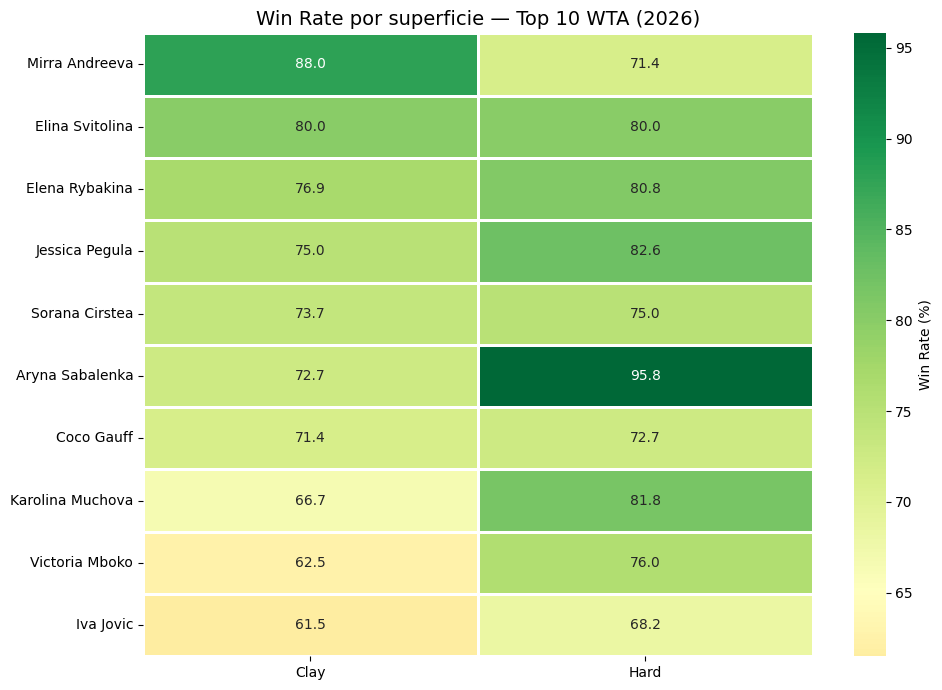

In [14]:
def heatmap_superficies(año=None, top_n=10):
    """Heatmap de win rate por superficie. Top dinámico por año."""
    if año:
        datos = df[df['tourney_date'].astype(str).str[:4] == str(año)]
        titulo = f'Win Rate por superficie — Top {top_n} WTA ({año})'
        archivo = f'../outputs/02_heatmap_superficies_{año}.png'
    else:
        datos = df
        titulo = f'Win Rate por superficie — Top {top_n} WTA (2020-2026)'
        archivo = '../outputs/02_heatmap_superficies_general.png'
    
    # Top dinámico: las jugadoras con más partidos en ESE período
    ganados = datos['winner_name'].value_counts()
    perdidos = datos['loser_name'].value_counts()
    total = (ganados.add(perdidos, fill_value=0)).astype(int).sort_values(ascending=False)
    top_jugadoras = total.head(top_n).index.tolist()
    
    superficies_disponibles = datos['surface'].dropna().unique().tolist()
    
    registros = []
    for jugadora in top_jugadoras:
        for superficie in superficies_disponibles:
            datos_sup = datos[datos['surface'] == superficie]
            wins = len(datos_sup[datos_sup['winner_name'] == jugadora])
            losses = len(datos_sup[datos_sup['loser_name'] == jugadora])
            total_p = wins + losses
            if total_p > 0:
                registros.append({
                    'jugadora': jugadora,
                    'superficie': superficie,
                    'win_rate': round(wins / total_p * 100, 1)
                })
    
    df_sup = pd.DataFrame(registros)
    pivot = df_sup.pivot(index='jugadora', columns='superficie', values='win_rate')
    pivot = pivot.sort_values(pivot.columns[0], ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=65,
                linewidths=1, ax=ax, cbar_kws={'label': 'Win Rate (%)'})
    
    ax.set_title(titulo, fontsize=14)
    ax.set_ylabel('')
    ax.set_xlabel('')
    
    plt.tight_layout()
    plt.savefig(archivo, dpi=100, bbox_inches='tight')
    plt.show()

heatmap_superficies(2026)

---
## 3. Head to Head — Sabalenka vs Gauff 🎾

La rivalidad más intensa del tenis femenino actual: 13 partidos, 7-6 Sabalenka, con el 54% de los encuentros extendiéndose a 3 sets.

In [15]:
# Encontrar todos los partidos entre Sabalenka y Gauff
h2h = df[
    ((df['winner_name'].str.contains('Sabalenka', case=False, na=False)) & 
     (df['loser_name'].str.contains('Gauff', case=False, na=False))) |
    ((df['winner_name'].str.contains('Gauff', case=False, na=False)) & 
     (df['loser_name'].str.contains('Sabalenka', case=False, na=False)))
].sort_values('tourney_date')

print(f"Enfrentamientos Sabalenka vs Gauff: {len(h2h)}\n")

print(f"{'Fecha':<12} {'Torneo':<30} {'Sup.':<8} {'Ronda':<6} {'Ganadora':<20} {'Score'}")
print("-" * 90)

for _, m in h2h.iterrows():
    fecha = str(m['tourney_date'])[:4] + '-' + str(m['tourney_date'])[4:6]
    torneo = str(m['tourney_name'])[:29]
    sup = str(m['surface'])
    ronda = str(m['round'])
    ganadora = str(m['winner_name'])
    score = str(m['score'])
    print(f"{fecha:<12} {torneo:<30} {sup:<8} {ronda:<6} {ganadora:<20} {score}")

wins_sab = len(h2h[h2h['winner_name'].str.contains('Sabalenka', na=False)])
wins_gauff = len(h2h[h2h['winner_name'].str.contains('Gauff', na=False)])

print(f"\n{'='*50}")
print(f"H2H: Sabalenka {wins_sab} - {wins_gauff} Gauff")

Enfrentamientos Sabalenka vs Gauff: 13

Fecha        Torneo                         Sup.     Ronda  Ganadora             Score
------------------------------------------------------------------------------------------
2020-08      Lexington                      Hard     R16    Coco Gauff           7-6(4) 4-6 6-4
2020-10      Ostrava                        Hard     R16    Aryna Sabalenka      1-6 7-5 7-6(2)
2021-05      Rome                           Clay     R16    Coco Gauff           7-5 6-3
2022-08      Toronto                        Hard     R16    Coco Gauff           7-5 4-6 7-6(4)
2023-03      Indian Wells                   Hard     QF     Aryna Sabalenka      6-4 6-0
2023-08      Us Open                        Hard     F      Coco Gauff           2-6 6-3 6-2
2024-01      Australian Open                Hard     SF     Aryna Sabalenka      7-6(2) 6-4
2024-10      Wuhan                          Hard     SF     Aryna Sabalenka      1-6 6-4 6-4
2024-11      Riyadh Finals            

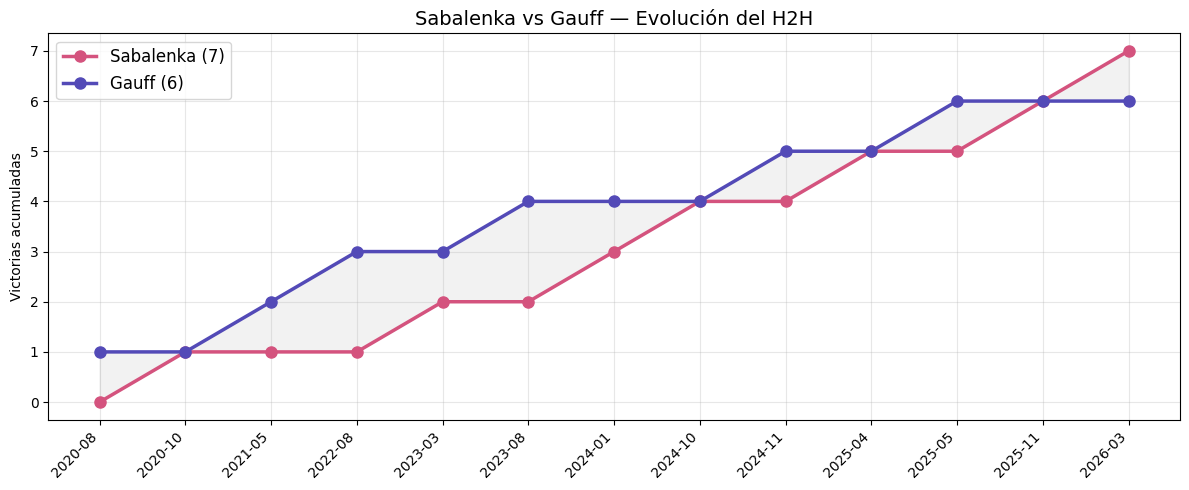

In [16]:
# Visualización del H2H
fig, ax = plt.subplots(figsize=(12, 5))

# Calcular H2H acumulado partido a partido
h2h_sorted = h2h.sort_values('tourney_date').reset_index(drop=True)
sab_acum = 0
gauff_acum = 0
fechas = []
sab_wins = []
gauff_wins = []

for _, m in h2h_sorted.iterrows():
    fecha = str(m['tourney_date'])[:4] + '-' + str(m['tourney_date'])[4:6]
    fechas.append(fecha)
    if 'Sabalenka' in str(m['winner_name']):
        sab_acum += 1
    else:
        gauff_acum += 1
    sab_wins.append(sab_acum)
    gauff_wins.append(gauff_acum)

ax.plot(fechas, sab_wins, 'o-', color='#D4537E', linewidth=2.5, 
        markersize=8, label=f'Sabalenka ({sab_acum})')
ax.plot(fechas, gauff_wins, 'o-', color='#534AB7', linewidth=2.5, 
        markersize=8, label=f'Gauff ({gauff_acum})')

ax.fill_between(range(len(fechas)), sab_wins, gauff_wins, alpha=0.1, color='gray')
ax.set_ylabel('Victorias acumuladas')
ax.set_title('Sabalenka vs Gauff — Evolución del H2H', fontsize=14)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../outputs/03_h2h_evolucion.png', dpi=100, bbox_inches='tight')
plt.show()

In [17]:
# Ver los niveles de torneo
print("Niveles de torneo en el dataset:\n")
for nivel, cantidad in df['tourney_level'].value_counts().sort_values(ascending=False).items():
    print(f"  {nivel}: {cantidad:,} partidos")

Niveles de torneo en el dataset:

  I: 4,755 partidos
  P: 4,036 partidos
  G: 3,175 partidos
  PM: 2,454 partidos
  D: 897 partidos
  W: 306 partidos
  50+H: 184 partidos
  O: 128 partidos
  F: 90 partidos
  35+H: 31 partidos


In [18]:
# Mapear niveles a nombres legibles
niveles = {
    'G': 'Grand Slam',
    'P': 'WTA 1000',
    'PM': 'WTA 1000 (Mandatory)',
    'I': 'WTA 250/500',
    'F': 'WTA Finals',
    'D': 'Billie Jean King Cup',
    'W': 'WTA 125',
    'O': 'Olimpiadas'
}

df['tourney_category'] = df['tourney_level'].map(niveles).fillna('Otro')

# Verificar
print("Categorías de torneo:\n")
for cat, cantidad in df['tourney_category'].value_counts().items():
    print(f"  {cat:<25} {cantidad:,} partidos")

Categorías de torneo:

  WTA 250/500               4,755 partidos
  WTA 1000                  4,036 partidos
  Grand Slam                3,175 partidos
  WTA 1000 (Mandatory)      2,454 partidos
  Billie Jean King Cup      897 partidos
  WTA 125                   306 partidos
  Otro                      215 partidos
  Olimpiadas                128 partidos
  WTA Finals                90 partidos


In [19]:
# H2H Sabalenka vs Gauff desglosado por categoría
h2h = df[
    ((df['winner_name'].str.contains('Sabalenka', case=False, na=False)) & 
     (df['loser_name'].str.contains('Gauff', case=False, na=False))) |
    ((df['winner_name'].str.contains('Gauff', case=False, na=False)) & 
     (df['loser_name'].str.contains('Sabalenka', case=False, na=False)))
].sort_values('tourney_date')

print("H2H Sabalenka vs Gauff — por categoría de torneo\n")
print(f"{'Categoría':<25} {'Sab':>5} {'Gauff':>5} {'Total':>6}")
print("-" * 45)

for cat in h2h['tourney_category'].unique():
    partidos_cat = h2h[h2h['tourney_category'] == cat]
    sab = len(partidos_cat[partidos_cat['winner_name'].str.contains('Sabalenka', na=False)])
    gauff = len(partidos_cat[partidos_cat['winner_name'].str.contains('Gauff', na=False)])
    print(f"{cat:<25} {sab:>5} {gauff:>5} {sab+gauff:>6}")

# Totales
sab_total = len(h2h[h2h['winner_name'].str.contains('Sabalenka', na=False)])
gauff_total = len(h2h[h2h['winner_name'].str.contains('Gauff', na=False)])
print("-" * 45)
print(f"{'TOTAL':<25} {sab_total:>5} {gauff_total:>5} {len(h2h):>6}")

H2H Sabalenka vs Gauff — por categoría de torneo

Categoría                   Sab Gauff  Total
---------------------------------------------
WTA 250/500                   0     1      1
WTA 1000                      1     1      2
WTA 1000 (Mandatory)          4     1      5
Grand Slam                    1     2      3
WTA Finals                    1     1      2
---------------------------------------------
TOTAL                         7     6     13


---
## 4. Análisis de servicio 🎯

Comparación de estadísticas de servicio entre las top jugadoras del tour.

In [20]:
def stats_servicio(año=None, top_n=10):
    """Estadísticas de servicio. Filtra por año si se pasa."""
    if año:
        datos = df[df['tourney_date'].astype(str).str[:4] == str(año)]
        titulo = f'Estadísticas de servicio — Top {top_n} WTA ({año})'
    else:
        datos = df
        titulo = f'Estadísticas de servicio — Top {top_n} WTA (2020-2026)'
    
    ganados_c = datos['winner_name'].value_counts()
    perdidos_c = datos['loser_name'].value_counts()
    total_p = (ganados_c.add(perdidos_c, fill_value=0)).astype(int).sort_values(ascending=False)
    top = total_p.head(top_n).index.tolist()
    
    registros = []
    for jugadora in top:
        como_ganadora = datos[datos['winner_name'] == jugadora]
        como_perdedora = datos[datos['loser_name'] == jugadora]
        
        n_w = len(como_ganadora)
        n_l = len(como_perdedora)
        total = n_w + n_l
        
        if total == 0:
            continue
        
        aces_prom = (como_ganadora['w_ace'].sum() + como_perdedora['l_ace'].sum()) / total
        df_prom = (como_ganadora['w_df'].sum() + como_perdedora['l_df'].sum()) / total
        
        bp_saved = como_ganadora['w_bpSaved'].sum() + como_perdedora['l_bpSaved'].sum()
        bp_faced = como_ganadora['w_bpFaced'].sum() + como_perdedora['l_bpFaced'].sum()
        bp_pct = (bp_saved / bp_faced * 100) if bp_faced > 0 else 0
        
        # Primer servicio adentro %
        sv1_in = como_ganadora['w_1stIn'].sum() + como_perdedora['l_1stIn'].sum()
        sv_pts = como_ganadora['w_svpt'].sum() + como_perdedora['l_svpt'].sum()
        sv1_pct = (sv1_in / sv_pts * 100) if sv_pts > 0 else 0
        
        # Puntos ganados con 1er servicio %
        sv1_won = como_ganadora['w_1stWon'].sum() + como_perdedora['l_1stWon'].sum()
        sv1_won_pct = (sv1_won / sv1_in * 100) if sv1_in > 0 else 0
        
        win_rate = n_w / total * 100
        
        registros.append({
            'jugadora': jugadora,
            'partidos': total,
            'win_rate': round(win_rate, 1),
            'aces_prom': round(aces_prom, 1),
            'df_prom': round(df_prom, 1),
            'sv1_in_pct': round(sv1_pct, 1),
            'sv1_won_pct': round(sv1_won_pct, 1),
            'bp_salv_pct': round(bp_pct, 1)
        })
    
    df_serv = pd.DataFrame(registros)
    
    print(f"\n{titulo}\n")
    print(f"{'Jugadora':<22} {'Part':>5} {'Win%':>6} {'Aces':>6} {'DF':>5} {'1stIn%':>7} {'1stW%':>7} {'BPSv%':>7}")
    print("-" * 68)
    for _, r in df_serv.iterrows():
        print(f"{r['jugadora']:<22} {r['partidos']:>5} {r['win_rate']:>5}% {r['aces_prom']:>5} {r['df_prom']:>5} {r['sv1_in_pct']:>6}% {r['sv1_won_pct']:>6}% {r['bp_salv_pct']:>6}%")
    
    return df_serv

# General
df_serv = stats_servicio()


Estadísticas de servicio — Top 10 WTA (2020-2026)

Jugadora                Part   Win%   Aces    DF  1stIn%   1stW%   BPSv%
--------------------------------------------------------------------
Iga Swiatek              415  81.4%   2.2   2.1   63.3%   68.6%   59.2%
Aryna Sabalenka          409  77.0%   4.7   4.0   61.5%   69.8%   60.4%
Elena Rybakina           399  71.2%   6.1   2.7   58.1%   72.6%   62.8%
Jessica Pegula           382  70.9%   2.7   2.4   60.3%   67.0%   58.6%
Coco Gauff               370  71.4%   3.5   5.3   61.0%   68.3%   56.8%
Elise Mertens            336  60.4%   3.6   4.8   57.6%   68.3%   55.7%
Daria Kasatkina          332  59.6%   1.5   4.1   68.7%   60.6%   53.3%
Ekaterina Alexandrova    329  58.7%   4.8   5.1   59.3%   69.3%   57.4%
Maria Sakkari            323  59.1%   3.5   3.3   59.7%   66.6%   59.5%
Jasmine Paolini          305  58.4%   1.1   1.8   67.3%   60.9%   55.0%


In [21]:
_ = stats_servicio(2025)


Estadísticas de servicio — Top 10 WTA (2025)

Jugadora                Part   Win%   Aces    DF  1stIn%   1stW%   BPSv%
--------------------------------------------------------------------
Jessica Pegula            76  69.7%   2.5   2.2   61.9%   67.5%   59.4%
Iga Swiatek               75  78.7%   3.1   2.9   61.3%   69.7%   57.4%
Elena Rybakina            75  74.7%   6.7   2.9   57.4%   74.8%   64.2%
Aryna Sabalenka           72  83.3%   3.8   2.2   62.7%   67.9%   64.2%
Ekaterina Alexandrova     71  66.2%   4.8   4.2   63.1%   69.3%   60.5%
Jasmine Paolini           64  68.8%   1.2   1.5   67.6%   61.6%   54.8%
Amanda Anisimova          63  73.0%   3.4   4.0   63.1%   66.2%   59.5%
Linda Noskova             63  60.3%   5.8   4.5   59.5%   70.1%   57.1%
Coco Gauff                60  73.3%   2.8   6.8   61.4%   67.7%   52.2%
Elise Mertens             57  63.2%   4.6   3.9   57.1%   70.3%   61.0%


In [22]:
_ = stats_servicio(2026)


Estadísticas de servicio — Top 10 WTA (2026)

Jugadora                Part   Win%   Aces    DF  1stIn%   1stW%   BPSv%
--------------------------------------------------------------------
Mirra Andreeva            46  80.4%   2.6   3.2   64.0%   67.3%   59.3%
Elina Svitolina           41  80.5%   3.0   2.6   60.5%   67.7%   64.1%
Elena Rybakina            39  79.5%   6.3   2.1   59.5%   72.3%   65.4%
Sorana Cirstea            39  74.4%   4.1   1.4   58.4%   69.3%   58.3%
Iva Jovic                 37  62.2%   1.9   1.8   61.7%   65.1%   55.4%
Coco Gauff                36  72.2%   1.9   5.0   64.9%   66.8%   53.7%
Jessica Pegula            35  80.0%   4.1   1.5   63.2%   70.7%   61.2%
Aryna Sabalenka           35  88.6%   3.9   1.6   65.7%   72.0%   66.4%
Victoria Mboko            33  72.7%   3.8   3.8   66.3%   66.7%   55.0%
Karolina Muchova          31  77.4%   2.6   1.2   65.8%   67.9%   60.6%


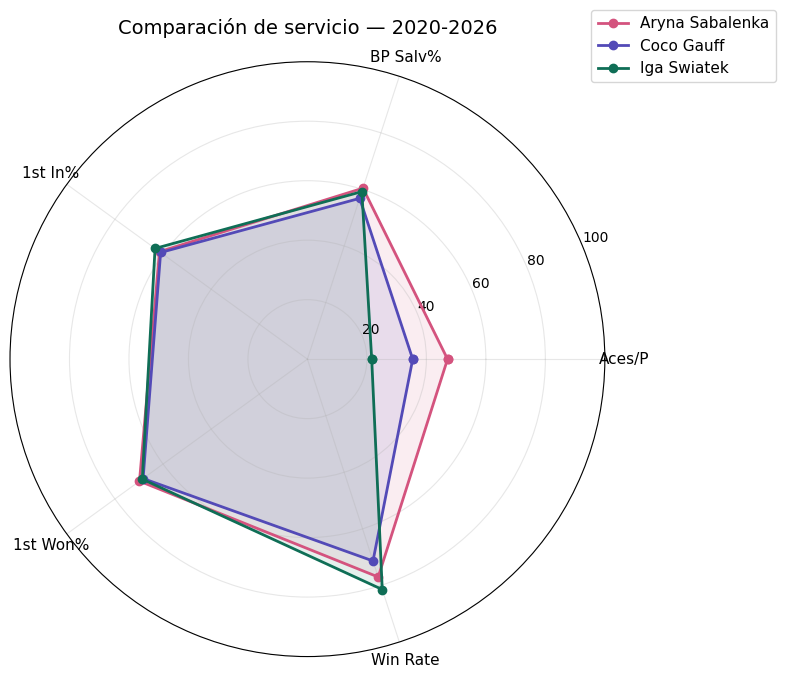

In [23]:
import numpy as np 

# Radar chart — Sabalenka vs Gauff vs Swiatek
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

def radar_jugadoras(jugadoras, año=None):
    """Radar chart comparando jugadoras seleccionadas."""
    if año:
        datos = df[df['tourney_date'].astype(str).str[:4] == str(año)]
        titulo = f'Comparación de servicio — {año}'
    else:
        datos = df
        titulo = 'Comparación de servicio — 2020-2026'
    
    categorias = ['Aces/P', 'BP Salv%', '1st In%', '1st Won%', 'Win Rate']
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    colores = ['#D4537E', '#534AB7', '#0F6E56', '#EF9F27']
    
    angulos = np.linspace(0, 2 * np.pi, len(categorias), endpoint=False).tolist()
    angulos += angulos[:1]
    
    for i, jugadora in enumerate(jugadoras):
        como_w = datos[datos['winner_name'] == jugadora]
        como_l = datos[datos['loser_name'] == jugadora]
        n_w, n_l = len(como_w), len(como_l)
        total = n_w + n_l
        
        if total == 0:
            continue
        
        aces = (como_w['w_ace'].sum() + como_l['l_ace'].sum()) / total
        bp_s = como_w['w_bpSaved'].sum() + como_l['l_bpSaved'].sum()
        bp_f = como_w['w_bpFaced'].sum() + como_l['l_bpFaced'].sum()
        bp_pct = (bp_s / bp_f * 100) if bp_f > 0 else 0
        sv1_in = como_w['w_1stIn'].sum() + como_l['l_1stIn'].sum()
        sv_pts = como_w['w_svpt'].sum() + como_l['l_svpt'].sum()
        sv1_pct = (sv1_in / sv_pts * 100) if sv_pts > 0 else 0
        sv1_won = como_w['w_1stWon'].sum() + como_l['l_1stWon'].sum()
        sv1_won_pct = (sv1_won / sv1_in * 100) if sv1_in > 0 else 0
        wr = n_w / total * 100
        
        # Normalizar para el radar (0-100)
        valores = [
            min(aces * 10, 100),  # aces escalados
            bp_pct,
            sv1_pct,
            sv1_won_pct,
            wr
        ]
        valores += valores[:1]
        
        ax.plot(angulos, valores, 'o-', linewidth=2, color=colores[i], label=jugadora)
        ax.fill(angulos, valores, alpha=0.1, color=colores[i])
    
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(categorias, fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_title(titulo, fontsize=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'../outputs/04_radar_servicio.png', dpi=100, bbox_inches='tight')
    plt.show()

radar_jugadoras(['Aryna Sabalenka', 'Coco Gauff', 'Iga Swiatek'])

#1stIn%	¿Cuántos primeros servicios mete? (precisión)
#1stW%	¿Cuántos puntos gana con el primer servicio? (potencia)

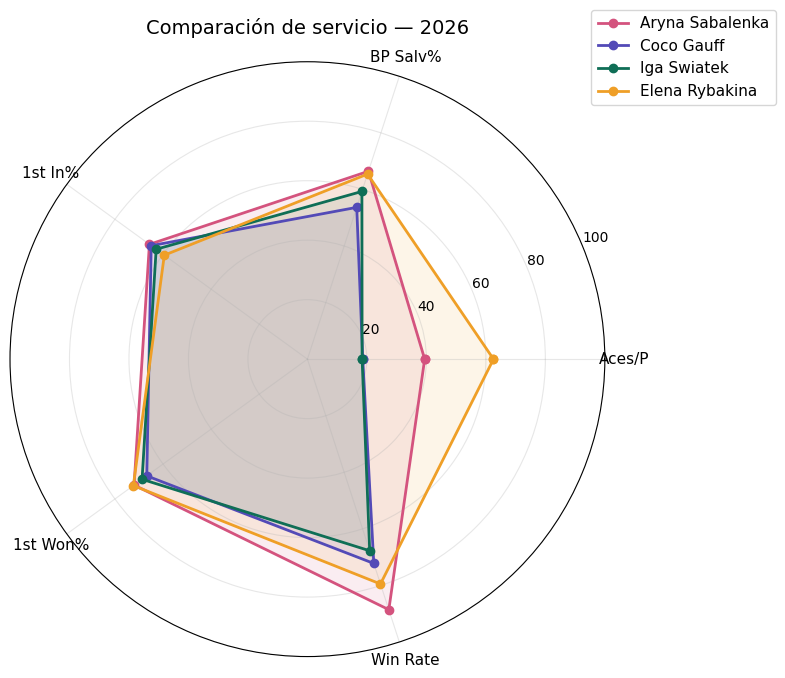

In [24]:
radar_jugadoras(['Aryna Sabalenka', 'Coco Gauff', 'Iga Swiatek', 'Elena Rybakina'], 2026)

---
## 5. Red de rivalidades 🕸️

Visualización de la estructura de rivalidades del tour WTA usando teoría de grafos.

In [25]:
pip install networkx

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\saray\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


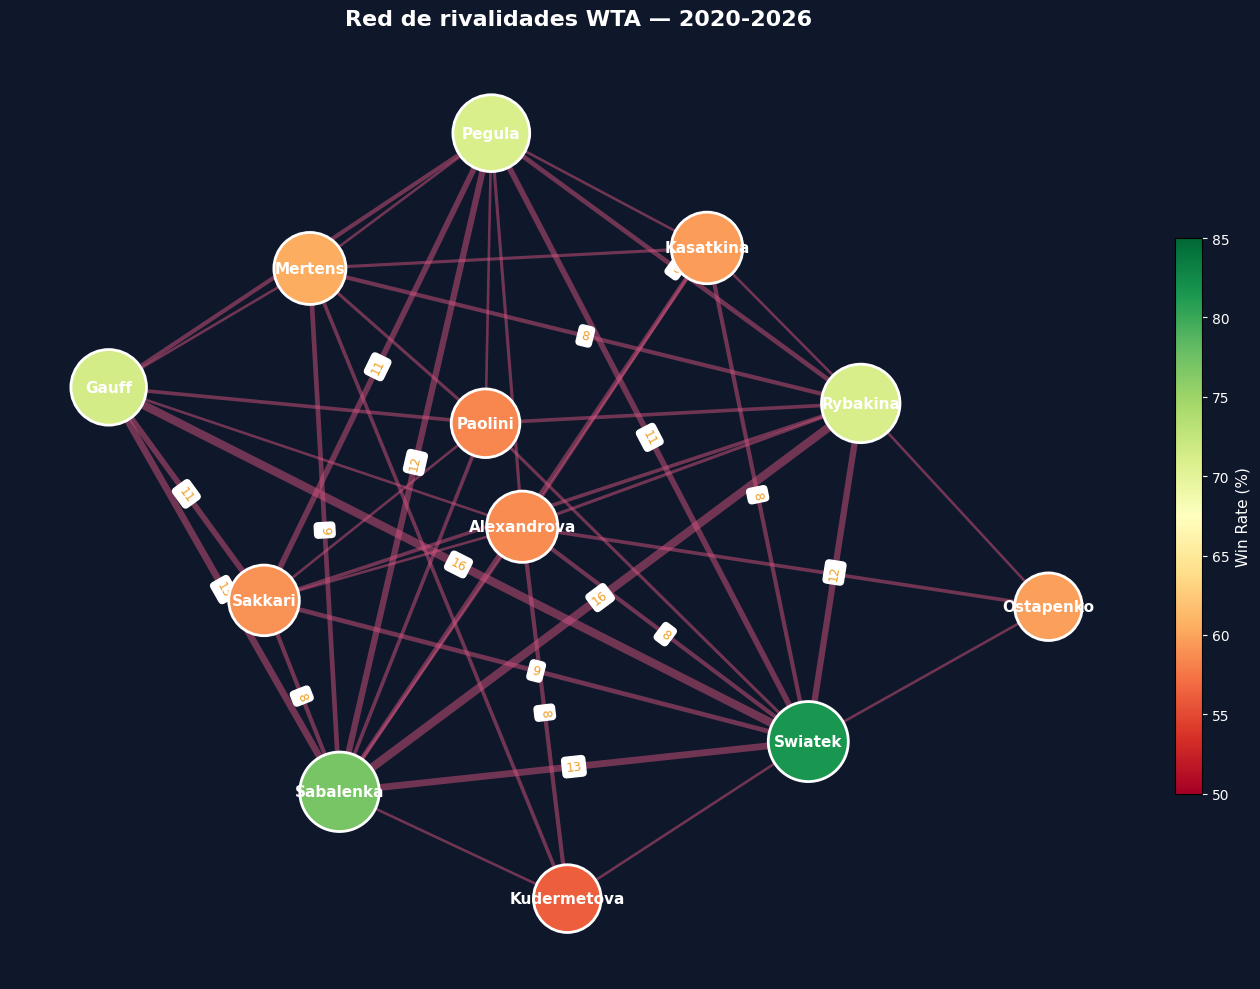

In [26]:
import networkx as nx

def red_rivalidades(año=None, min_partidos=5, top_jugadoras=12):
    """Grafo de rivalidades WTA — versión limpia."""
    if año:
        datos = df[df['tourney_date'].astype(str).str[:4] == str(año)]
        titulo = f'Red de rivalidades WTA — {año}'
    else:
        datos = df
        titulo = 'Red de rivalidades WTA — 2020-2026'
    
    ganados = datos['winner_name'].value_counts()
    perdidos = datos['loser_name'].value_counts()
    total = (ganados.add(perdidos, fill_value=0)).astype(int).sort_values(ascending=False)
    top = total.head(top_jugadoras).index.tolist()
    
    G = nx.Graph()
    
    for i, j1 in enumerate(top):
        for j2 in top[i+1:]:
            n_partidos = len(datos[
                ((datos['winner_name'] == j1) & (datos['loser_name'] == j2)) |
                ((datos['winner_name'] == j2) & (datos['loser_name'] == j1))
            ])
            if n_partidos >= min_partidos:
                G.add_edge(j1, j2, weight=n_partidos)
    
    # Agregar nodos sueltos que no tienen rivalidades con min_partidos
    for j in top:
        if j not in G.nodes():
            G.add_node(j)
    
    fig, ax = plt.subplots(figsize=(14, 10), facecolor='#0F172A')
    ax.set_facecolor('#0F172A')
    
    pos = nx.kamada_kawai_layout(G)
    
    # Win rate para colores de nodos
    node_colors = []
    node_sizes = []
    for jugadora in G.nodes():
        w = ganados.get(jugadora, 0)
        t = total.get(jugadora, 1)
        wr = w / t
        node_colors.append(wr)
        node_sizes.append(t * 8)
    
    # Edges
    edges = G.edges(data=True)
    weights = [e[2].get('weight', 1) for e in edges]
    max_w = max(weights) if weights else 1
    
    nx.draw_networkx_edges(G, pos, ax=ax,
                           width=[w / max_w * 6 for w in weights],
                           alpha=0.5, edge_color='#D4537E',
                           style='solid')
    
    # Nodos
    nodos = nx.draw_networkx_nodes(G, pos, ax=ax,
                                   node_size=node_sizes,
                                   node_color=node_colors,
                                   cmap=plt.cm.RdYlGn,
                                   vmin=0.5, vmax=0.85,
                                   edgecolors='white', linewidths=2)
    
    # Labels — solo apellido
    labels = {n: n.split()[-1] for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, ax=ax,
                           font_size=11, font_weight='bold',
                           font_color='white')
    
    # Solo mostrar cantidad en rivalidades grandes
    edge_labels = {(e[0], e[1]): str(e[2]['weight']) 
                   for e in edges if e[2].get('weight', 0) >= 8}
    nx.draw_networkx_edge_labels(G, pos, edge_labels, ax=ax,
                                font_size=9, font_color='#EF9F27')
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn, norm=plt.Normalize(50, 85))
    cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('Win Rate (%)', color='white', fontsize=11)
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')
    
    ax.set_title(titulo, fontsize=16, color='white', pad=20, fontweight='bold')
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('../outputs/05_red_rivalidades.png', dpi=150, bbox_inches='tight',
                facecolor="#0B0E14")
    plt.show()

red_rivalidades()

In [27]:
# H2H por superficie
print("H2H Sabalenka vs Gauff — por superficie\n")

for superficie in ['Hard', 'Clay', 'Grass']:
    partidos_sup = h2h[h2h['surface'] == superficie]
    
    if len(partidos_sup) == 0:
        print(f"  {superficie}: sin enfrentamientos\n")
        continue
    
    sab = len(partidos_sup[partidos_sup['winner_name'].str.contains('Sabalenka', na=False)])
    gauff = len(partidos_sup[partidos_sup['winner_name'].str.contains('Gauff', na=False)])
    
    print(f"  {superficie}: Sabalenka {sab} - {gauff} Gauff ({len(partidos_sup)} partidos)")
    
    for _, m in partidos_sup.iterrows():
        fecha = str(m['tourney_date'])[:4] + '-' + str(m['tourney_date'])[4:6]
        ganadora = m['winner_name'].split()[-1]
        print(f"    {fecha} | {m['tourney_name']:<25} | {ganadora:<12} | {m['score']}")
    print()

H2H Sabalenka vs Gauff — por superficie

  Hard: Sabalenka 6 - 4 Gauff (10 partidos)
    2020-08 | Lexington                 | Gauff        | 7-6(4) 4-6 6-4
    2020-10 | Ostrava                   | Sabalenka    | 1-6 7-5 7-6(2)
    2022-08 | Toronto                   | Gauff        | 7-5 4-6 7-6(4)
    2023-03 | Indian Wells              | Sabalenka    | 6-4 6-0
    2023-08 | Us Open                   | Gauff        | 2-6 6-3 6-2
    2024-01 | Australian Open           | Sabalenka    | 7-6(2) 6-4
    2024-10 | Wuhan                     | Sabalenka    | 1-6 6-4 6-4
    2024-11 | Riyadh Finals             | Gauff        | 7-6(4) 6-3
    2025-11 | Riyadh Finals             | Sabalenka    | 7-6(5) 6-2
    2026-03 | Miami                     | Sabalenka    | 6-2 4-6 6-3

  Clay: Sabalenka 1 - 2 Gauff (3 partidos)
    2021-05 | Rome                      | Gauff        | 7-5 6-3
    2025-04 | Madrid                    | Sabalenka    | 6-3 7-6(3)
    2025-05 | Roland Garros             | Gauf

In [28]:
# Análisis de intensidad del H2H
sets_3 = 0
sets_2 = 0
minutos_total = []

print("Intensidad del H2H — Sabalenka vs Gauff\n")

for _, m in h2h.sort_values('tourney_date').iterrows():
    score = str(m['score'])
    n_sets = score.count('-')
    mins = m['minutes']
    
    if n_sets == 3:
        sets_3 += 1
        intensidad = "🔥 3 sets"
    else:
        sets_2 += 1
        intensidad = "   2 sets"
    
    if pd.notna(mins):
        minutos_total.append(mins)
        dur = f"{int(mins)} min"
    else:
        dur = "N/A"
    
    fecha = str(m['tourney_date'])[:4] + '-' + str(m['tourney_date'])[4:6]
    ganadora = m['winner_name'].split()[-1]
    print(f"  {fecha} | {ganadora:<12} | {score:<20} | {dur:<8} | {intensidad}")

print(f"\n{'='*50}")
print(f"Partidos a 2 sets: {sets_2} ({sets_2/len(h2h)*100:.0f}%)")
print(f"Partidos a 3 sets: {sets_3} ({sets_3/len(h2h)*100:.0f}%)")

if minutos_total:
    print(f"\nDuración promedio: {np.mean(minutos_total):.0f} minutos")
    print(f"Partido más largo: {max(minutos_total):.0f} minutos")
    print(f"Partido más corto: {min(minutos_total):.0f} minutos")

Intensidad del H2H — Sabalenka vs Gauff

  2020-08 | Gauff        | 7-6(4) 4-6 6-4       | 168 min  | 🔥 3 sets
  2020-10 | Sabalenka    | 1-6 7-5 7-6(2)       | 133 min  | 🔥 3 sets
  2021-05 | Gauff        | 7-5 6-3              | 89 min   |    2 sets
  2022-08 | Gauff        | 7-5 4-6 7-6(4)       | 191 min  | 🔥 3 sets
  2023-03 | Sabalenka    | 6-4 6-0              | 64 min   |    2 sets
  2023-08 | Gauff        | 2-6 6-3 6-2          | 126 min  | 🔥 3 sets
  2024-01 | Sabalenka    | 7-6(2) 6-4           | 102 min  |    2 sets
  2024-10 | Sabalenka    | 1-6 6-4 6-4          | 146 min  | 🔥 3 sets
  2024-11 | Gauff        | 7-6(4) 6-3           | 109 min  |    2 sets
  2025-04 | Sabalenka    | 6-3 7-6(3)           | 99 min   |    2 sets
  2025-05 | Gauff        | 6-7(5) 6-2 6-4       | N/A      | 🔥 3 sets
  2025-11 | Sabalenka    | 7-6(5) 6-2           | 88 min   |    2 sets
  2026-03 | Sabalenka    | 6-2 4-6 6-3          | 129 min  | 🔥 3 sets

Partidos a 2 sets: 6 (46%)
Partidos a 3 se

---
## 6. Modelo predictivo 🤖

¿Se puede predecir quién va a ganar un partido WTA usando solo datos pre-partido?

In [29]:
# Preparar features para predicción de partidos
# Cada fila = un partido. Features = características de ambas jugadoras.

print("Preparando datos para modelo predictivo...\n")

# Verificar qué columnas numéricas tenemos disponibles
cols_stats = ['w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon',
              'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt', 'l_1stIn',
              'l_1stWon', 'l_2ndWon', 'l_bpSaved', 'l_bpFaced']

# ¿Cuántos partidos tienen estadísticas completas?
con_stats = df[cols_stats].dropna()
sin_stats = len(df) - len(con_stats)

print(f"Partidos totales:          {len(df):,}")
print(f"Con estadísticas completas: {len(con_stats):,} ({len(con_stats)/len(df)*100:.1f}%)")
print(f"Sin estadísticas:          {sin_stats:,} ({sin_stats/len(df)*100:.1f}%)")

Preparando datos para modelo predictivo...

Partidos totales:          16,056
Con estadísticas completas: 15,284 (95.2%)
Sin estadísticas:          772 (4.8%)


In [30]:
# Crear dataset para el modelo
# El truco: el dataset tiene "winner" y "loser" pero eso YA dice quién ganó.
# Para el modelo necesitamos "player_1" y "player_2" sin revelar quién ganó.

df_model = df.dropna(subset=cols_stats).copy()

# Asignar aleatoriamente quién es player_1 y quién es player_2
np.random.seed(42)
swap = np.random.random(len(df_model)) > 0.5

# Features
model_data = pd.DataFrame()

# Cuando NO swap: player_1 = winner, player_2 = loser
# Cuando SÍ swap: player_1 = loser, player_2 = winner
model_data['rank_1'] = np.where(swap, df_model['loser_rank'], df_model['winner_rank'])
model_data['rank_2'] = np.where(swap, df_model['winner_rank'], df_model['loser_rank'])
model_data['age_1'] = np.where(swap, df_model['loser_age'], df_model['winner_age'])
model_data['age_2'] = np.where(swap, df_model['winner_age'], df_model['loser_age'])
model_data['surface'] = df_model['surface'].values

# Feature derivada: diferencia de ranking
model_data['rank_diff'] = model_data['rank_1'] - model_data['rank_2']
model_data['age_diff'] = model_data['age_1'] - model_data['age_2']

# Target: ¿ganó player_1?
model_data['target'] = np.where(swap, 0, 1)

# Encoding de superficie
model_data = pd.get_dummies(model_data, columns=['surface'], drop_first=True)

# Eliminar nulos
model_data = model_data.dropna()

print(f"Dataset para modelo: {model_data.shape}")
print(f"Target balance: {model_data['target'].mean()*100:.1f}% ganó player_1")
print(f"\nFeatures:")
for col in model_data.columns:
    if col != 'target':
        print(f"  {col}")

Dataset para modelo: (15102, 9)
Target balance: 50.6% ganó player_1

Features:
  rank_1
  rank_2
  age_1
  age_2
  rank_diff
  age_diff
  surface_Grass
  surface_Hard


In [31]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# Reconstruir todo limpio
cols_stats = ['w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon',
              'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt', 'l_1stIn',
              'l_1stWon', 'l_2ndWon', 'l_bpSaved', 'l_bpFaced']

df_limpio = df.dropna(subset=cols_stats + ['winner_rank', 'loser_rank', 'winner_age', 'loser_age']).copy()
df_limpio = df_limpio.reset_index(drop=True)
df_limpio['year'] = df_limpio['tourney_date'].astype(str).str[:4].astype(int)

# Swap aleatorio para eliminar sesgo winner/loser
np.random.seed(42)
swap = np.random.random(len(df_limpio)) > 0.5

model_data = pd.DataFrame({
    'rank_1': np.where(swap, df_limpio['loser_rank'], df_limpio['winner_rank']),
    'rank_2': np.where(swap, df_limpio['winner_rank'], df_limpio['loser_rank']),
    'age_1': np.where(swap, df_limpio['loser_age'], df_limpio['winner_age']),
    'age_2': np.where(swap, df_limpio['winner_age'], df_limpio['loser_age']),
    'surface': df_limpio['surface'].values,
    'year': df_limpio['year'].values,
    'target': np.where(swap, 0, 1)
})

model_data['rank_diff'] = model_data['rank_1'] - model_data['rank_2']
model_data['age_diff'] = model_data['age_1'] - model_data['age_2']
model_data = pd.get_dummies(model_data, columns=['surface'], drop_first=True)

# Split temporal
X_train = model_data[model_data['year'] <= 2024].drop(['target', 'year'], axis=1)
y_train = model_data[model_data['year'] <= 2024]['target']
X_test = model_data[model_data['year'] >= 2025].drop(['target', 'year'], axis=1)
y_test = model_data[model_data['year'] >= 2025]['target']

print(f"Train (2020-2024): {len(X_train):,} partidos")
print(f"Test (2025-2026):  {len(X_test):,} partidos")
print(f"\nTarget en train: {y_train.mean()*100:.1f}%")
print(f"Target en test:  {y_test.mean()*100:.1f}%")

Train (2020-2024): 11,403 partidos
Test (2025-2026):  3,699 partidos

Target en train: 50.5%
Target en test:  50.9%


In [32]:
# Entrenar 3 modelos
resultados = {}

# 1. Logística (baseline)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]
resultados['Logística'] = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'auc': roc_auc_score(y_test, y_proba_lr)
}

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
resultados['Random Forest'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'auc': roc_auc_score(y_test, y_proba_rf)
}

# 3. XGBoost
xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
resultados['XGBoost'] = {
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'auc': roc_auc_score(y_test, y_proba_xgb)
}

# Comparación
print("Comparación de modelos — Predicción de partidos WTA\n")
print(f"{'Modelo':<20} {'Accuracy':>10} {'AUC-ROC':>10}")
print("-" * 42)
for modelo, metricas in resultados.items():
    print(f"{modelo:<20} {metricas['accuracy']*100:>9.1f}% {metricas['auc']*100:>9.1f}%")

Comparación de modelos — Predicción de partidos WTA

Modelo                 Accuracy    AUC-ROC
------------------------------------------
Logística                 61.7%      66.3%
Random Forest             61.7%      67.6%
XGBoost                   61.7%      67.6%


In [33]:
# Calcular estadísticas históricas PREVIAS de cada jugadora
# Para cada partido, calculamos el promedio de stats de los últimos 20 partidos

print("Calculando estadísticas históricas por jugadora...\n")

# Función para calcular stats históricas de una jugadora ANTES de una fecha
def stats_historicas(nombre, fecha, datos, n_ultimos=20):
    """Stats promedio de los últimos n partidos ANTES de esta fecha."""
    # Partidos anteriores como ganadora
    como_w = datos[(datos['winner_name'] == nombre) & (datos['tourney_date'] < fecha)]
    # Partidos anteriores como perdedora
    como_l = datos[(datos['loser_name'] == nombre) & (datos['tourney_date'] < fecha)]
    
    # Tomar los últimos n partidos
    partidos_w = como_w.tail(n_ultimos)
    partidos_l = como_l.tail(n_ultimos)
    
    total = len(partidos_w) + len(partidos_l)
    if total < 5:  # mínimo 5 partidos de historia
        return None
    
    # Win rate reciente
    win_rate = len(partidos_w) / total
    
    # Aces promedio
    aces = (partidos_w['w_ace'].sum() + partidos_l['l_ace'].sum()) / total
    
    # Doble faltas promedio
    dfs = (partidos_w['w_df'].sum() + partidos_l['l_df'].sum()) / total
    
    # BP salvados %
    bp_saved = partidos_w['w_bpSaved'].sum() + partidos_l['l_bpSaved'].sum()
    bp_faced = partidos_w['w_bpFaced'].sum() + partidos_l['l_bpFaced'].sum()
    bp_pct = bp_saved / bp_faced if bp_faced > 0 else 0.5
    
    return {
        'win_rate_hist': win_rate,
        'aces_hist': aces,
        'df_hist': dfs,
        'bp_pct_hist': bp_pct
    }

# Aplicar a cada partido (esto puede tardar 2-3 minutos)
print("Procesando... puede tardar 2-3 minutos")

registros_mejorados = []
for idx, row in df_limpio.iterrows():
    fecha = row['tourney_date']
    
    stats_w = stats_historicas(row['winner_name'], fecha, df_limpio)
    stats_l = stats_historicas(row['loser_name'], fecha, df_limpio)
    
    if stats_w is None or stats_l is None:
        continue
    
    swap = np.random.random() > 0.5
    
    if swap:
        p1_name, p2_name = row['loser_name'], row['winner_name']
        p1_stats, p2_stats = stats_l, stats_w
        target = 0
    else:
        p1_name, p2_name = row['winner_name'], row['loser_name']
        p1_stats, p2_stats = stats_w, stats_l
        target = 1
    
    registros_mejorados.append({
        'rank_1': row['loser_rank'] if swap else row['winner_rank'],
        'rank_2': row['winner_rank'] if swap else row['loser_rank'],
        'rank_diff': (row['loser_rank'] if swap else row['winner_rank']) - 
                     (row['winner_rank'] if swap else row['loser_rank']),
        'wr_diff': p1_stats['win_rate_hist'] - p2_stats['win_rate_hist'],
        'aces_diff': p1_stats['aces_hist'] - p2_stats['aces_hist'],
        'bp_diff': p1_stats['bp_pct_hist'] - p2_stats['bp_pct_hist'],
        'surface_Hard': 1 if row['surface'] == 'Hard' else 0,
        'surface_Grass': 1 if row['surface'] == 'Grass' else 0,
        'year': int(str(row['tourney_date'])[:4]),
        'target': target
    })
    
    if idx % 3000 == 0:
        print(f"  Progreso: {idx:,} / {len(df_limpio):,}")

df_mejorado = pd.DataFrame(registros_mejorados)
print(f"\n✓ Dataset mejorado: {len(df_mejorado):,} partidos con stats históricas")
print(f"Features: {[c for c in df_mejorado.columns if c not in ['target', 'year']]}")

Calculando estadísticas históricas por jugadora...

Procesando... puede tardar 2-3 minutos
  Progreso: 3,000 / 15,102
  Progreso: 6,000 / 15,102
  Progreso: 9,000 / 15,102
  Progreso: 12,000 / 15,102
  Progreso: 15,000 / 15,102

✓ Dataset mejorado: 12,667 partidos con stats históricas
Features: ['rank_1', 'rank_2', 'rank_diff', 'wr_diff', 'aces_diff', 'bp_diff', 'surface_Hard', 'surface_Grass']


In [35]:
# Split temporal con datos mejorados
X_train2 = df_mejorado[df_mejorado['year'] <= 2024].drop(['target', 'year'], axis=1)
y_train2 = df_mejorado[df_mejorado['year'] <= 2024]['target']
X_test2 = df_mejorado[df_mejorado['year'] >= 2025].drop(['target', 'year'], axis=1)
y_test2 = df_mejorado[df_mejorado['year'] >= 2025]['target']

# Entrenar los 3 modelos con features mejoradas
resultados2 = {}

lr2 = LogisticRegression(random_state=42, max_iter=1000)
lr2.fit(X_train2, y_train2)
resultados2['Logística'] = {
    'accuracy': accuracy_score(y_test2, lr2.predict(X_test2)),
    'auc': roc_auc_score(y_test2, lr2.predict_proba(X_test2)[:, 1])
}

rf2 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf2.fit(X_train2, y_train2)
resultados2['Random Forest'] = {
    'accuracy': accuracy_score(y_test2, rf2.predict(X_test2)),
    'auc': roc_auc_score(y_test2, rf2.predict_proba(X_test2)[:, 1])
}

xgb2 = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
xgb2.fit(X_train2, y_train2)
resultados2['XGBoost'] = {
    'accuracy': accuracy_score(y_test2, xgb2.predict(X_test2)),
    'auc': roc_auc_score(y_test2, xgb2.predict_proba(X_test2)[:, 1])
}

# Comparación: antes vs después
print("IMPACTO DEL FEATURE ENGINEERING\n")
print(f"{'Modelo':<20} {'Acc ANTES':>10} {'Acc DESPUÉS':>12} {'AUC ANTES':>10} {'AUC DESPUÉS':>12}")
print("-" * 66)
for modelo in resultados.keys():
    a_antes = resultados[modelo]['accuracy'] * 100
    a_desp = resultados2[modelo]['accuracy'] * 100
    auc_antes = resultados[modelo]['auc'] * 100
    auc_desp = resultados2[modelo]['auc'] * 100
    print(f"{modelo:<20} {a_antes:>9.1f}% {a_desp:>11.1f}% {auc_antes:>9.1f}% {auc_desp:>11.1f}%")

IMPACTO DEL FEATURE ENGINEERING

Modelo                Acc ANTES  Acc DESPUÉS  AUC ANTES  AUC DESPUÉS
------------------------------------------------------------------
Logística                 61.7%        62.6%      66.3%        65.9%
Random Forest             61.7%        61.8%      67.6%        68.0%
XGBoost                   61.7%        61.6%      67.6%        67.0%


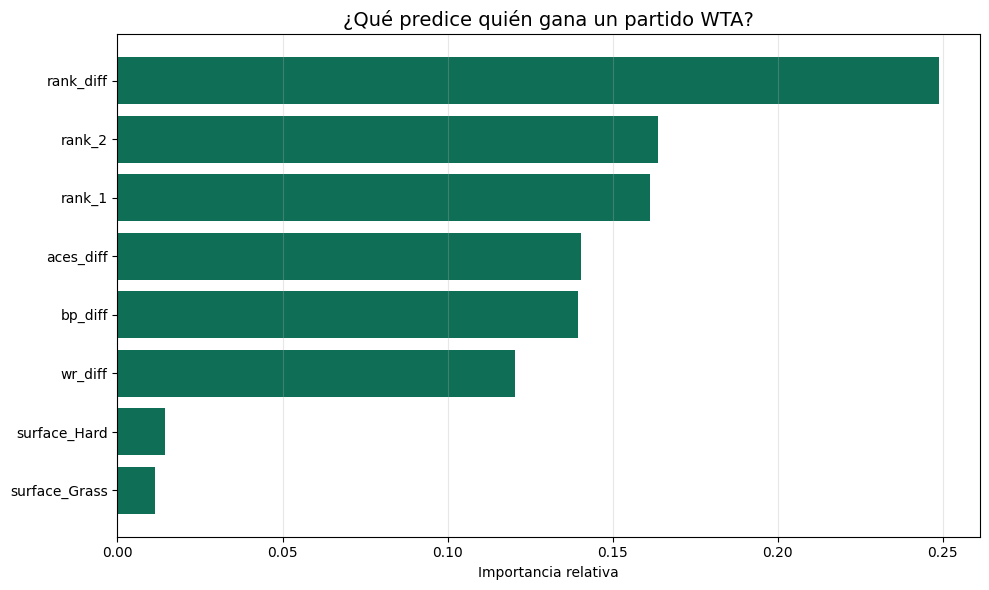

In [36]:
# Feature importance del mejor modelo (Random Forest)
importancias = pd.DataFrame({
    'feature': X_train2.columns,
    'importancia': rf2.feature_importances_
}).sort_values('importancia', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importancias['feature'], importancias['importancia'], color='#0F6E56')
ax.set_xlabel('Importancia relativa')
ax.set_title('¿Qué predice quién gana un partido WTA?', fontsize=14)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/06_feature_importance_prediccion.png', dpi=100, bbox_inches='tight')
plt.show()

## Diccionario de features del modelo predictivo

| Feature | Significado | Interpretación |
|---|---|---|
| `rank_diff` | Diferencia de ranking entre jugadora 1 y jugadora 2 | Positivo = jugadora 1 peor rankeada. Negativo = jugadora 1 mejor rankeada |
| `rank_1` | Ranking WTA de la jugadora 1 | Menor número = mejor posición (1 = la mejor del mundo) |
| `rank_2` | Ranking WTA de la jugadora 2 | Menor número = mejor posición |
| `aces_diff` | Diferencia de aces promedio (últimos 20 partidos) | Positivo = jugadora 1 saca más aces que jugadora 2 |
| `bp_diff` | Diferencia en % de break points salvados (últimos 20 partidos) | Positivo = jugadora 1 es más clutch bajo presión |
| `wr_diff` | Diferencia de win rate reciente (últimos 20 partidos) | Positivo = jugadora 1 viene ganando más que jugadora 2 |
| `surface_Hard` | ¿El partido es en cancha dura? | 1 = Hard, 0 = no |
| `surface_Grass` | ¿El partido es en pasto? | 1 = Grass, 0 = no (si ambas son 0 = Clay) |

### Hallazgo clave

El **ranking** domina la predicción (rank_diff = 25%, rank_1 + rank_2 = 32%). Es el factor más importante para predecir quién gana. Sin embargo, las features de rendimiento reciente (aces, break points, win rate) aportan un 40% combinado — confirmando que la **forma actual** importa más allá de la posición en el ranking.

La **superficie** aporta muy poco (<2%) — sorprendente pero explicable: la ventaja de una jugadora sobre otra se manifiesta ya en las stats históricas y el ranking, no en la superficie en sí.

In [37]:
# Predecir: Sabalenka vs Gauff — próximo enfrentamiento
# Usamos las stats históricas más recientes de cada una

stats_sab = stats_historicas('Aryna Sabalenka', 99999999, df_limpio, n_ultimos=20)
stats_gauff = stats_historicas('Coco Gauff', 99999999, df_limpio, n_ultimos=20)

# Obtener ranking más reciente
rank_sab = df_limpio[df_limpio['winner_name'] == 'Aryna Sabalenka']['winner_rank'].iloc[-1]
rank_gauff = df_limpio[df_limpio['winner_name'] == 'Coco Gauff']['winner_rank'].iloc[-1]

print("PERFIL ACTUAL\n")
print(f"{'Stat':<25} {'Sabalenka':>12} {'Gauff':>12}")
print("-" * 50)
print(f"{'Ranking':.<25} {int(rank_sab):>12} {int(rank_gauff):>12}")
print(f"{'Win Rate (últ 20)':.<25} {stats_sab['win_rate_hist']*100:>11.1f}% {stats_gauff['win_rate_hist']*100:>11.1f}%")
print(f"{'Aces promedio':.<25} {stats_sab['aces_hist']:>12.1f} {stats_gauff['aces_hist']:>12.1f}")
print(f"{'BP Salvados %':.<25} {stats_sab['bp_pct_hist']*100:>11.1f}% {stats_gauff['bp_pct_hist']*100:>11.1f}%")

# Predicción por superficie
print(f"\n{'='*55}")
print("PREDICCIÓN POR SUPERFICIE")
print(f"{'='*55}\n")

for superficie, hard_val, grass_val in [('Hard', 1, 0), ('Clay', 0, 0), ('Grass', 0, 1)]:
    # Sabalenka como player_1
    features = pd.DataFrame([{
        'rank_1': rank_sab,
        'rank_2': rank_gauff,
        'rank_diff': rank_sab - rank_gauff,
        'wr_diff': stats_sab['win_rate_hist'] - stats_gauff['win_rate_hist'],
        'aces_diff': stats_sab['aces_hist'] - stats_gauff['aces_hist'],
        'bp_diff': stats_sab['bp_pct_hist'] - stats_gauff['bp_pct_hist'],
        'surface_Hard': hard_val,
        'surface_Grass': grass_val
    }])
    
    prob_sab = rf2.predict_proba(features)[0][1]
    prob_gauff = 1 - prob_sab
    
    ganadora = "🟢 Sabalenka" if prob_sab > 0.5 else "🟢 Gauff"
    
    print(f"  {superficie:<8} → Sabalenka {prob_sab*100:.1f}% | Gauff {prob_gauff*100:.1f}%  {ganadora}")

print(f"\n📊 Modelo: Random Forest (AUC: 68.0%)")
print(f"📅 Basado en datos hasta Roland Garros 2026")

PERFIL ACTUAL

Stat                         Sabalenka        Gauff
--------------------------------------------------
Ranking..................            1            4
Win Rate (últ 20)........        50.0%        50.0%
Aces promedio............          4.3          2.4
BP Salvados %............        60.5%        50.6%

PREDICCIÓN POR SUPERFICIE

  Hard     → Sabalenka 61.3% | Gauff 38.7%  🟢 Sabalenka
  Clay     → Sabalenka 64.3% | Gauff 35.7%  🟢 Sabalenka
  Grass    → Sabalenka 53.6% | Gauff 46.4%  🟢 Sabalenka

📊 Modelo: Random Forest (AUC: 68.0%)
📅 Basado en datos hasta Roland Garros 2026


## Predicción vs Realidad — Los límites del modelo

El modelo predice ventaja de Sabalenka en las 3 superficies, basándose en su ranking (#1), mayor potencia de servicio (4.3 aces/partido vs 2.4) y mejor porcentaje de break points salvados (60.5% vs 50.6%).

Sin embargo, **el H2H real en Clay es 2-1 a favor de Gauff**, incluyendo la final de Roland Garros 2025.

**¿Qué no captura el modelo?**

1. **Factor mental:** Gauff tiene un historial de elevar su nivel en los momentos más grandes contra Sabalenka, especialmente en Grand Slams (2-1 Gauff)
2. **Contexto del partido:** ronda, presión, público — variables difíciles de cuantificar
3. **Forma del momento:** el win rate de los últimos 20 partidos (50% para ambas) promedia rachas buenas y malas sin distinguir la tendencia

**Reflexión profesional:** un modelo predictivo es una herramienta, no una verdad absoluta. En tenis (y en cualquier dominio), las variables psicológicas y contextuales pueden superar las estadísticas. Por eso los modelos de predicción de tenis profesionales rara vez superan el 70% de accuracy — hay un techo natural dado por la incertidumbre humana.

In [38]:
def predecir_partido(jugadora_1, jugadora_2, superficie='Hard'):
    """Predice quién gana entre dos jugadoras en una superficie."""
    
    # Buscar stats históricas
    stats_1 = stats_historicas(jugadora_1, 99999999, df_limpio, n_ultimos=20)
    stats_2 = stats_historicas(jugadora_2, 99999999, df_limpio, n_ultimos=20)
    
    if stats_1 is None:
        print(f"❌ No hay suficientes datos de {jugadora_1}")
        return
    if stats_2 is None:
        print(f"❌ No hay suficientes datos de {jugadora_2}")
        return
    
    # Buscar ranking más reciente
    rank_1_w = df_limpio[df_limpio['winner_name'] == jugadora_1]['winner_rank']
    rank_1_l = df_limpio[df_limpio['loser_name'] == jugadora_1]['loser_rank']
    rank_1 = pd.concat([rank_1_w, rank_1_l]).iloc[-1]
    
    rank_2_w = df_limpio[df_limpio['winner_name'] == jugadora_2]['winner_rank']
    rank_2_l = df_limpio[df_limpio['loser_name'] == jugadora_2]['loser_rank']
    rank_2 = pd.concat([rank_2_w, rank_2_l]).iloc[-1]
    
    # Armar features
    features = pd.DataFrame([{
        'rank_1': rank_1,
        'rank_2': rank_2,
        'rank_diff': rank_1 - rank_2,
        'wr_diff': stats_1['win_rate_hist'] - stats_2['win_rate_hist'],
        'aces_diff': stats_1['aces_hist'] - stats_2['aces_hist'],
        'bp_diff': stats_1['bp_pct_hist'] - stats_2['bp_pct_hist'],
        'surface_Hard': 1 if superficie == 'Hard' else 0,
        'surface_Grass': 1 if superficie == 'Grass' else 0
    }])
    
    # Predecir
    prob_1 = rf2.predict_proba(features)[0][1]
    prob_2 = 1 - prob_1
    
    # Mostrar resultado
    print(f"\n{'='*55}")
    print(f"  🎾 {jugadora_1} vs {jugadora_2}")
    print(f"  📍 Superficie: {superficie}")
    print(f"{'='*55}")
    print(f"\n  {'Stat':<20} {jugadora_1.split()[-1]:>12} {jugadora_2.split()[-1]:>12}")
    print(f"  {'-'*46}")
    print(f"  {'Ranking':<20} {int(rank_1):>12} {int(rank_2):>12}")
    print(f"  {'Win Rate reciente':<20} {stats_1['win_rate_hist']*100:>11.1f}% {stats_2['win_rate_hist']*100:>11.1f}%")
    print(f"  {'Aces/partido':<20} {stats_1['aces_hist']:>12.1f} {stats_2['aces_hist']:>12.1f}")
    print(f"  {'BP Salvados':<20} {stats_1['bp_pct_hist']*100:>11.1f}% {stats_2['bp_pct_hist']*100:>11.1f}%")
    print(f"\n  📊 PREDICCIÓN:")
    print(f"  {jugadora_1.split()[-1]}: {prob_1*100:.1f}%")
    print(f"  {jugadora_2.split()[-1]}: {prob_2*100:.1f}%")
    
    ganadora = jugadora_1 if prob_1 > prob_2 else jugadora_2
    print(f"\n  🏆 Favorita: {ganadora}")

print("✓ Función predecir_partido() lista")

✓ Función predecir_partido() lista


In [40]:
predecir_partido('Naomi Osaka', 'Elena Rybakina', 'Hard')


  🎾 Naomi Osaka vs Elena Rybakina
  📍 Superficie: Hard

  Stat                        Osaka     Rybakina
  ----------------------------------------------
  Ranking                        16            2
  Win Rate reciente           50.0%        50.0%
  Aces/partido                  6.3          6.7
  BP Salvados                 53.8%        60.8%

  📊 PREDICCIÓN:
  Osaka: 29.3%
  Rybakina: 70.7%

  🏆 Favorita: Elena Rybakina


In [41]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\saray\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [42]:
import joblib

# Guardar el modelo y los datos necesarios
joblib.dump(rf2, '../modelo_rf_wta.pkl')
joblib.dump(df_limpio, '../datos_wta.pkl')

print("✓ Modelo y datos guardados")

✓ Modelo y datos guardados
